In [1]:
import sys;from pathlib import Path;sys.path.insert(0, str(Path().resolve()))

import torch
from transformers import CLIPTokenizer
from PIL import Image
from IPython.display import display, clear_output
import random

from module import model_loader, pipeline

torch.set_float32_matmul_precision('high')
DEVICE = "cuda" if torch.cuda.is_available() else 'cpu'
DTYPE = torch.bfloat16 if DEVICE=="cuda" else torch.bfloat32
DEVICE, DTYPE

('cuda', torch.bfloat16)

In [6]:
tokenizer = CLIPTokenizer("tokenizer/vocab.json", "tokenizer/merges.txt")
models = model_loader.get_models("model/Anime-Background-Finetuning-diffusion.safetensors", device=DEVICE, dtype=DTYPE)

🔄 Initializing vae, clip and diffusion...
> Loading encoder from model/Anime-Background-Finetuning-diffusion.safetensors...
> Loading decoder from model/Anime-Background-Finetuning-diffusion.safetensors...
> Loading clip from model/Anime-Background-Finetuning-diffusion.safetensors...
> Loading diffusion from model/Anime-Background-Finetuning-diffusion.safetensors...
✅ Initialization successful!


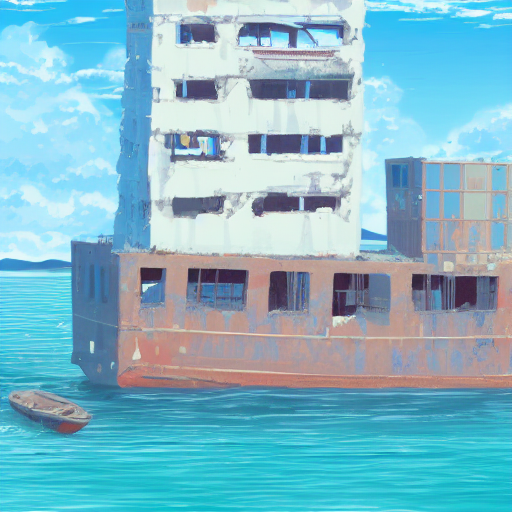

Sampling: 100%|██████████| 67/67 [00:12<00:00,  5.36step/s]


In [7]:
prompt = """airfish_(lefko_d), architecture, blue sky, blurry, boat, broken window, building, city, day,\
depth of field, drum (container), no humans, outdoors, ruins, scenery, science fiction, sign, signature, sky, water, watercraft"""
uncond_prompt = ""

##### Generated size
img_width = 512
img_height = 512

##### Generation parameters
do_cfg = True
cfg_scale = 7.0
num_inference_steps = 64
num_training_steps = 1000
seed = random.randint(0, int(1e8))
decode_interval = 10

##### Image to image
#input_image = Image.open("image/image_0003.png").convert("RGB")
input_image = None
strength = 0.6

##### Sampler
#sampler_name = "ddpm"
sampler_name = "ddpm"
ddim_eta = 0.2

##### GENERATION LOOP
generator = pipeline.generate(
    prompt=prompt,
    uncond_prompt=uncond_prompt,
    img_width=img_width,
    img_height=img_height,
    input_image=input_image,
    strength=strength,
    do_cfg=do_cfg,
    cfg_scale=cfg_scale,
    sampler_name=sampler_name,
    n_inference_steps=num_inference_steps,
    num_training_steps=num_training_steps,
    models=models,
    seed=seed,
    device=DEVICE,
    dtype=DTYPE,
    tokenizer=tokenizer,
    ddim_eta=ddim_eta,
    decode_interval=decode_interval
)
for output_image in generator:
    pil_img = Image.fromarray(output_image[0])
    clear_output(wait=True)
    display(pil_img)